<a href="https://colab.research.google.com/github/Fajtos/hzmps-surveillance/blob/main/Influenza_Mortality_us_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Third Empirical Application: US Influenza Mortality (CDC FluView)

**Purpose:** Extend the empirical evaluation to a third dataset from a
completely independent surveillance system. This application uses weekly
influenza mortality counts from the US CDC National Center for Health
Statistics, reported by all 50 US states plus DC.

**Why this dataset:**
- Independent of the Brazilian InfoDengue system (no shared reporting artefacts)
- Real positive counts, not dominated by zeros
- Known to exhibit both zero-inflation (summer weeks) and zero-deflation
  (winter peak weeks) within the same panel
- Direct test of whether HZMPS's flexibility translates into improved
  predictive performance when the zero process is genuinely mixed

**Data source:** CDC Provisional Death Counts by Week Ending Date and State
(Dataset ID: r8kw-7aab). Publicly available at data.cdc.gov.

**Design:** N = 51 states, T = 104 weeks (2022-W01 to 2023-W52). Same model
structure and priors across all four models (HZMPS, ZIP, ZINB, HNB).

In [1]:
# CELL 2: SETUP
!pip install --upgrade cmdstanpy -q

import os, urllib.request, shutil
CMDSTAN_DIR = '/content/cmdstan-2.36.0'
if not os.path.exists(os.path.join(CMDSTAN_DIR, 'makefile')):
    os.chdir('/content')
    tgz_file = '/content/colab-cmdstan-2.36.0.tar.gz'
    tgz_url = ('https://github.com/stan-dev/cmdstan/releases/download/'
               'v2.36.0/colab-cmdstan-2.36.0.tgz')
    if not os.path.exists(tgz_file):
        urllib.request.urlretrieve(tgz_url, tgz_file)
    shutil.unpack_archive(tgz_file, '/content')
os.environ['CMDSTAN'] = CMDSTAN_DIR

import cmdstanpy, numpy as np, pandas as pd, requests, io, time
print(f"CmdStan: {cmdstanpy.cmdstan_version()}")

CmdStan: (2, 36)


In [2]:
# CELL 3: DOWNLOAD CDC INFLUENZA MORTALITY DATA
# Dataset: Provisional Death Counts by Week Ending Date and State
# DOI: 10.6084/m9.figshare.13188789

url = "https://data.cdc.gov/api/views/r8kw-7aab/rows.csv?accessType=DOWNLOAD"

print("Downloading CDC influenza mortality data...")
r = requests.get(url, timeout=60)
r.raise_for_status()

df_raw = pd.read_csv(io.StringIO(r.text))
print(f"Downloaded: {len(df_raw)} rows")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df_raw.head())

Downloaded: 23760 rows
Columns: ['Data as of', 'Start Date', 'End Date', 'Group', 'Year', 'Month', 'MMWR Week', 'Week Ending Date', 'State', 'COVID-19 Deaths', 'Total Deaths', 'Percent of Expected Deaths', 'Pneumonia Deaths', 'Pneumonia and COVID-19 Deaths', 'Influenza Deaths', 'Pneumonia, Influenza, or COVID-19 Deaths', 'Footnote']

First 5 rows:
   Data as of  Start Date    End Date    Group       Year  Month  MMWR Week  \
0  09/24/2026  12/29/2019  01/04/2020  By Week  2019/2020    NaN        1.0   
1  09/24/2026  01/05/2020  01/11/2020  By Week       2020    NaN        2.0   
2  09/24/2026  01/12/2020  01/18/2020  By Week       2020    NaN        3.0   
3  09/24/2026  01/19/2020  01/25/2020  By Week       2020    NaN        4.0   
4  09/24/2026  01/26/2020  02/01/2020  By Week       2020    NaN        5.0   

  Week Ending Date          State  COVID-19 Deaths  Total Deaths  \
0       01/04/2020  United States              0.0       60170.0   
1       01/11/2020  United States      

In [4]:
# ============================================================
# CELL 4 (corrected): BUILD INFLUENZA MORTALITY PANEL
# ============================================================
import pandas as pd
import numpy as np

# --- Parse dates robustly ---
# Some rows have NaN in the date column. Convert with errors='coerce'
# and then drop the NaN rows.

df_raw['date'] = pd.to_datetime(df_raw['Week Ending Date'], errors='coerce')

# Drop rows with invalid or missing dates
n_before = len(df_raw)
df_raw = df_raw.dropna(subset=['date']).reset_index(drop=True)
n_dropped = n_before - len(df_raw)
print(f"Dropped {n_dropped} rows with missing/invalid dates")
print(f"Remaining: {len(df_raw)} rows")

# --- Extract year and ISO week ---
df_raw['year'] = df_raw['date'].dt.year
df_raw['week'] = df_raw['date'].dt.isocalendar().week
df_raw['week'] = df_raw['week'].astype(int)
df_raw['time_idx'] = df_raw['year'] * 100 + df_raw['week']

# --- Filter to 2022-2023 ---
df_filtered = df_raw[(df_raw['year'] >= 2022) & (df_raw['year'] <= 2023)].copy()
print(f"\nFiltered to 2022-2023: {len(df_filtered)} rows")

# --- Exclude non-state jurisdictions ---
# We want the 50 US states plus DC. Exclude Puerto Rico, NYC, and any
# "United States" aggregate rows.
exclude_pattern = 'Puerto Rico|New York City|United States|District of Columbia'
df_filtered = df_filtered[
    ~df_filtered['State'].str.contains(exclude_pattern, case=False, na=False)
]
print(f"After excluding non-state jurisdictions: {len(df_filtered)} rows, "
      f"{df_filtered['State'].nunique()} states")

# --- Also filter out "Group" rows (CDC includes group aggregations) ---
if 'Group' in df_filtered.columns:
    df_filtered = df_filtered[df_filtered['Group'] == 'By Week']
    print(f"After filtering to 'By Week': {len(df_filtered)} rows")

# --- Handle missing influenza deaths ---
# Some weeks may have NaN; treat as zero (no reported deaths that week)
df_filtered['Influenza Deaths'] = df_filtered['Influenza Deaths'].fillna(0)

# --- Pivot to wide format ---
panel = df_filtered.pivot_table(
    index='State',
    columns='time_idx',
    values='Influenza Deaths',
    aggfunc='sum'
).fillna(0)

# --- Truncate to last 104 weeks ---
if panel.shape[1] > 104:
    panel = panel.iloc[:, -104:]
elif panel.shape[1] < 104:
    print(f"Warning: only {panel.shape[1]} weeks available")

Y = panel.values.astype(int)
N, T = panel.shape
M = N * T

print(f"\nPanel shape: N={N}, T={T}, M={M}")
print(f"Zero fraction: {(Y==0).mean():.3f}")
print(f"Mean count: {Y.mean():.3f}")
print(f"Max count: {Y.max()}")
print(f"Number of positive observations: {(Y>0).sum()}")

# --- Sanity check ---
if Y.max() < 2:
    print("\n⚠️ WARNING: Very few non-zero observations. This dataset may be too sparse.")
elif (Y==0).mean() > 0.95:
    print("\n⚠️ WARNING: Extremely high zero fraction. Model comparison may not be meaningful.")
else:
    print("\n✅ Data density looks reasonable for model comparison.")

# --- Prepare for Stan ---
y_flat   = Y.flatten().tolist()
unit_idx = np.repeat(np.arange(1, N+1), T).tolist()
time_idx = np.tile(np.arange(1, T+1), N).tolist()

base_data = {
    'N': N, 'T': T, 'G': 10,
    'y': y_flat, 'unit': unit_idx, 'time': time_idx,
    'a_dirichlet': 2.0, 'delta_min': 0.3,
    'grainsize': max(1, int(M / 8)),
}
print("\nData prepared for Stan.")

Dropped 4806 rows with missing/invalid dates
Remaining: 18954 rows

Filtered to 2022-2023: 5670 rows
After excluding non-state jurisdictions: 5250 rows, 50 states
After filtering to 'By Week': 5250 rows

Panel shape: N=50, T=104, M=5200
Zero fraction: 0.931
Mean count: 1.571
Max count: 99
Number of positive observations: 358

✅ Data density looks reasonable for model comparison.

Data prepared for Stan.


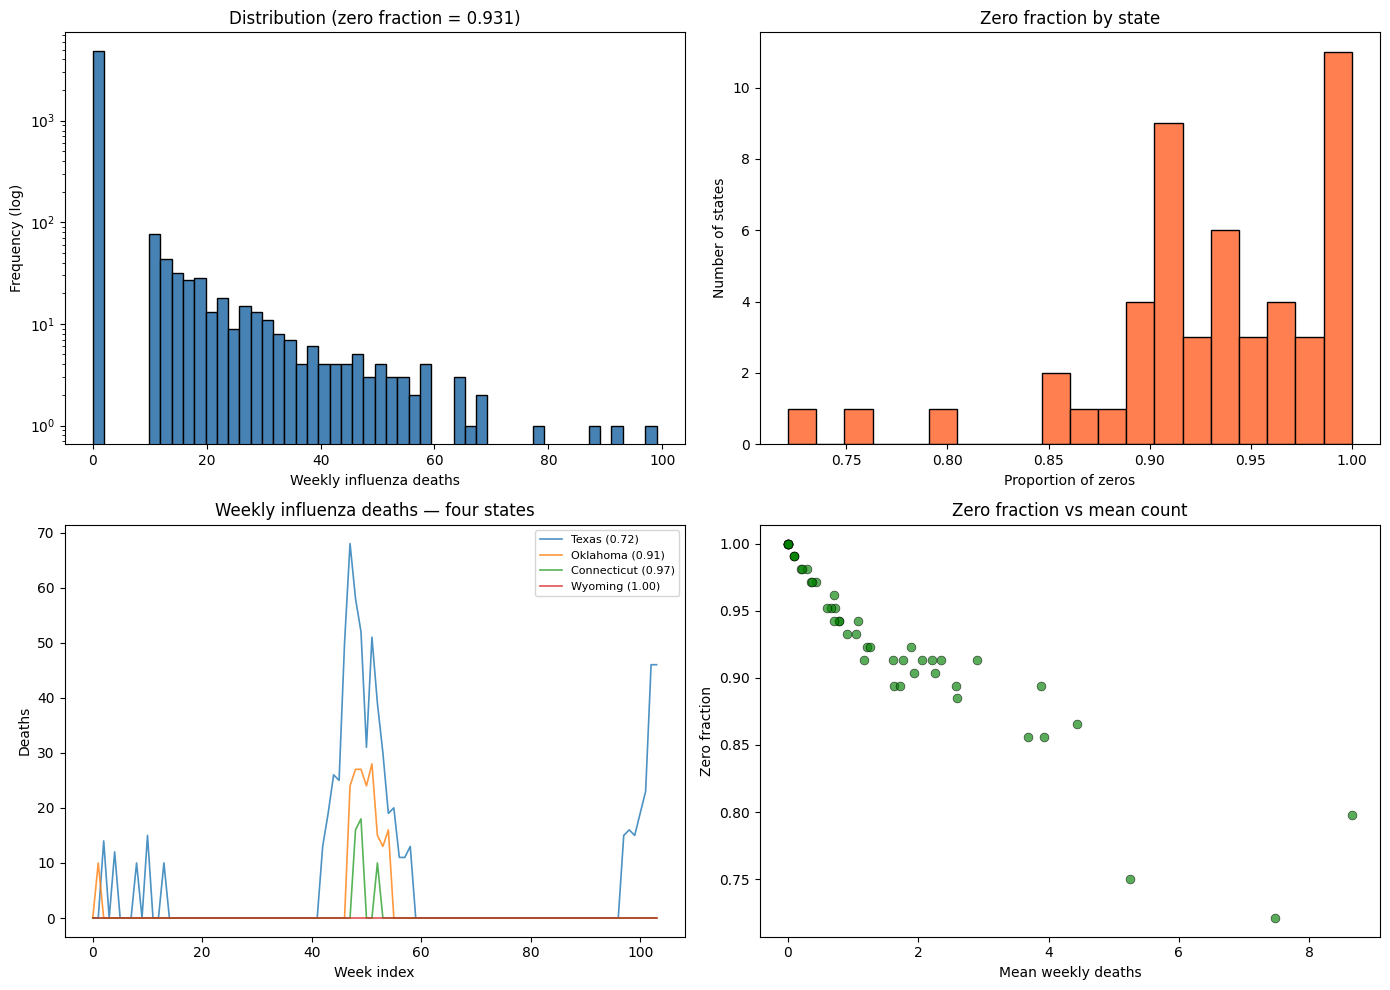

Exploratory plot saved.


In [5]:
# CELL 5: EXPLORATORY PLOTS
import matplotlib.pyplot as plt
import numpy as np

mun_stats = pd.DataFrame({
    'unit_id': panel.index,
    'zero_frac': (Y == 0).mean(axis=1),
    'mean_count': Y.mean(axis=1),
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Distribution ---
axes[0, 0].hist(Y.flatten(), bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Weekly influenza deaths')
axes[0, 0].set_ylabel('Frequency (log)')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title(f'Distribution (zero fraction = {(Y==0).mean():.3f})')

# --- Panel 2: Zero fraction by state ---
axes[0, 1].hist(mun_stats['zero_frac'], bins=20, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Proportion of zeros')
axes[0, 1].set_ylabel('Number of states')
axes[0, 1].set_title('Zero fraction by state')

# --- Panel 3: Time series for 4 states ---
sorted_idx = np.argsort(mun_stats['zero_frac'].values)
state_names = panel.index.tolist()
chosen = [sorted_idx[0], sorted_idx[len(sorted_idx)//3],
          sorted_idx[2*len(sorted_idx)//3], sorted_idx[-1]]
for i in chosen:
    axes[1, 0].plot(Y[i], alpha=0.8, linewidth=1.2,
                    label=f"{state_names[i]} ({mun_stats['zero_frac'].iloc[i]:.2f})")
axes[1, 0].set_xlabel('Week index')
axes[1, 0].set_ylabel('Deaths')
axes[1, 0].legend(fontsize=8)
axes[1, 0].set_title('Weekly influenza deaths — four states')

# --- Panel 4: Mean vs zero fraction ---
axes[1, 1].scatter(mun_stats['mean_count'], mun_stats['zero_frac'],
                  alpha=0.65, s=40, color='green', edgecolor='black', linewidth=0.5)
axes[1, 1].set_xlabel('Mean weekly deaths')
axes[1, 1].set_ylabel('Zero fraction')
axes[1, 1].set_title('Zero fraction vs mean count')

plt.tight_layout()
plt.savefig('/content/flu_exploratory.png', dpi=150)
plt.show()
print("Exploratory plot saved.")

In [6]:
# CELL 6: WRITE BASELINE STAN MODELS
# Same three baseline models as before.
# The same code that worked for dengue/chikungunya/Zika.)

zip_code = r"""
functions {
  real partial_sum_zip(array[] int y_slice, int start, int end,
                       array[] int unit, array[] int time,
                       vector pi_i, matrix mu) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m]; int t = time[m];
      if (y_slice[k] == 0)
        lp += log_sum_exp(log(pi_i[i]), log1m(pi_i[i]) - mu[i, t]);
      else
        lp += log1m(pi_i[i]) + y_slice[k]*log(mu[i,t]) - mu[i,t]
              - lgamma(y_slice[k]+1);
    }
    return lp;
  }
}
data {
  int<lower=1> N; int<lower=1> T; int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet; real<lower=0> delta_min;
  int<lower=1> grainsize;
}
transformed data { int<lower=0> M = N * T; }
parameters {
  real mu_eta1; vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta; simplex[G] w;
  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
}
transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T) zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }
  vector[N] pi_i;
  for (i in 1:N) pi_i[i] = inv_logit(eta[i]);
  matrix[N, T] mu;
  for (i in 1:N) for (t in 1:T) mu[i, t] = exp(beta0_mu + zeta[i, t]);
}
model {
  mu_eta1 ~ normal(0, 3);
  gamma_raw ~ normal(-1, 1);
  sigma_eta ~ normal(0, 1);
  w ~ dirichlet(rep_vector(a_dirichlet / G, G));
  beta0_mu ~ normal(0, 5);
  rho_zeta ~ uniform(-0.99, 0.99);
  sigma_zeta ~ normal(0, 1);
  to_vector(zeta_raw) ~ std_normal();
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }
  target += reduce_sum(partial_sum_zip, y, grainsize, unit, time, pi_i, mu);
}
generated quantities {
  vector[M] log_lik;
  for (m in 1:M) {
    int i = unit[m]; int t = time[m];
    if (y[m] == 0) log_lik[m] = log_sum_exp(log(pi_i[i]), log1m(pi_i[i]) - mu[i,t]);
    else log_lik[m] = log1m(pi_i[i]) + y[m]*log(mu[i,t]) - mu[i,t] - lgamma(y[m]+1);
  }
}
"""

zinb_code = r"""
functions {
  real partial_sum_zinb(array[] int y_slice, int start, int end,
                        array[] int unit, array[] int time,
                        vector pi_i, matrix mu, real phi) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m]; int t = time[m];
      real mu_it = mu[i, t];
      real nb0 = phi * log(phi / (phi + mu_it));
      if (y_slice[k] == 0) {
        lp += log_sum_exp(log(pi_i[i]), log1m(pi_i[i]) + nb0);
      } else {
        real log_nb = lgamma(y_slice[k] + phi) - lgamma(phi)
                      - lgamma(y_slice[k] + 1)
                      + phi * log(phi / (phi + mu_it))
                      + y_slice[k] * log(mu_it / (phi + mu_it));
        lp += log1m(pi_i[i]) + log_nb;
      }
    }
    return lp;
  }
}
data {
  int<lower=1> N; int<lower=1> T; int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet; real<lower=0> delta_min;
  int<lower=1> grainsize;
}
transformed data { int<lower=0> M = N * T; }
parameters {
  real mu_eta1; vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta; simplex[G] w;
  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
  real<lower=0> phi;
}
transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T) zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }
  vector[N] pi_i;
  for (i in 1:N) pi_i[i] = inv_logit(eta[i]);
  matrix[N, T] mu;
  for (i in 1:N) for (t in 1:T) mu[i, t] = exp(beta0_mu + zeta[i, t]);
}
model {
  mu_eta1 ~ normal(0, 3);
  gamma_raw ~ normal(-1, 1);
  sigma_eta ~ normal(0, 1);
  w ~ dirichlet(rep_vector(a_dirichlet / G, G));
  beta0_mu ~ normal(0, 5);
  rho_zeta ~ uniform(-0.99, 0.99);
  sigma_zeta ~ normal(0, 1);
  phi ~ normal(0, 5);
  to_vector(zeta_raw) ~ std_normal();
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }
  target += reduce_sum(partial_sum_zinb, y, grainsize, unit, time, pi_i, mu, phi);
}
generated quantities {
  vector[M] log_lik;
  for (m in 1:M) {
    int i = unit[m]; int t = time[m];
    real mu_it = mu[i, t];
    real log_nb = lgamma(y[m] + phi) - lgamma(phi) - lgamma(y[m] + 1)
                  + phi * log(phi / (phi + mu_it))
                  + y[m] * log(mu_it / (phi + mu_it));
    if (y[m] == 0)
      log_lik[m] = log_sum_exp(log(pi_i[i]),
                               log1m(pi_i[i]) + phi * log(phi / (phi + mu_it)));
    else
      log_lik[m] = log1m(pi_i[i]) + log_nb;
  }
}
"""

hnb_code = r"""
functions {
  real partial_sum_hnb(array[] int y_slice, int start, int end,
                       array[] int unit, array[] int time,
                       vector omega, matrix mu, real phi) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m]; int t = time[m];
      real mu_it = mu[i, t];
      real nb0 = phi * log(phi / (phi + mu_it));
      real log_norm = log1m_exp(nb0);
      if (y_slice[k] == 0) {
        lp += log1m(omega[i]);
      } else {
        real log_nb = lgamma(y_slice[k] + phi) - lgamma(phi)
                      - lgamma(y_slice[k] + 1)
                      + phi * log(phi / (phi + mu_it))
                      + y_slice[k] * log(mu_it / (phi + mu_it));
        lp += log(omega[i]) + log_nb - log_norm;
      }
    }
    return lp;
  }
}
data {
  int<lower=1> N; int<lower=1> T; int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet; real<lower=0> delta_min;
  int<lower=1> grainsize;
}
transformed data { int<lower=0> M = N * T; }
parameters {
  real mu_eta1; vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta; simplex[G] w;
  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
  real<lower=0> phi;
}
transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T) zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }
  vector[N] omega;
  for (i in 1:N) omega[i] = inv_logit(eta[i]);
  matrix[N, T] mu;
  for (i in 1:N) for (t in 1:T) mu[i, t] = exp(beta0_mu + zeta[i, t]);
}
model {
  mu_eta1 ~ normal(0, 3);
  gamma_raw ~ normal(-1, 1);
  sigma_eta ~ normal(0, 1);
  w ~ dirichlet(rep_vector(a_dirichlet / G, G));
  beta0_mu ~ normal(0, 5);
  rho_zeta ~ uniform(-0.99, 0.99);
  sigma_zeta ~ normal(0, 1);
  phi ~ normal(0, 5);
  to_vector(zeta_raw) ~ std_normal();
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }
  target += reduce_sum(partial_sum_hnb, y, grainsize, unit, time, omega, mu, phi);
}
generated quantities {
  vector[M] log_lik;
  for (m in 1:M) {
    int i = unit[m]; int t = time[m];
    real mu_it = mu[i, t];
    real nb0 = phi * log(phi / (phi + mu_it));
    real log_norm = log1m_exp(nb0);
    real log_nb = lgamma(y[m] + phi) - lgamma(phi) - lgamma(y[m] + 1)
                  + phi * log(phi / (phi + mu_it))
                  + y[m] * log(mu_it / (phi + mu_it));
    if (y[m] == 0) log_lik[m] = log1m(omega[i]);
    else log_lik[m] = log(omega[i]) + log_nb - log_norm;
  }
}
"""

with open('/content/zip_ss.stan', 'w') as f:
    f.write(zip_code)
with open('/content/zinb_ss.stan', 'w') as f:
    f.write(zinb_code)
with open('/content/hnb_ss.stan', 'w') as f:
    f.write(hnb_code)

print("Wrote ZIP, ZINB, HNB Stan files.")

Wrote ZIP, ZINB, HNB Stan files.


In [7]:
# CELL 7: WRITE HZMPS MODEL AND COMPILE ALL FOUR
hzmps_stan = r"""
functions {
  real partial_sum_hzmps(array[] int y_slice, int start, int end,
                         array[] int unit, array[] int time,
                         vector omega, matrix mu) {
    real lp = 0;
    for (k in 1:size(y_slice)) {
      int m = start + k - 1;
      int i = unit[m]; int t = time[m];
      if (y_slice[k] == 0) lp += log1m(omega[i]);
      else lp += log(omega[i]) - mu[i,t] + y_slice[k]*log(mu[i,t])
                 - lgamma(y_slice[k]+1) - log1m_exp(-mu[i,t]);
    }
    return lp;
  }
}
data {
  int<lower=1> N; int<lower=1> T; int<lower=1> G;
  array[N*T] int<lower=0> y;
  array[N*T] int<lower=1> unit;
  array[N*T] int<lower=1> time;
  real<lower=0> a_dirichlet; real<lower=0> delta_min;
  int<lower=1> grainsize;
}
transformed data { int<lower=0> M = N * T; }
parameters {
  real mu_eta1; vector[G-1] gamma_raw;
  real<lower=0> sigma_eta;
  vector[N] eta; simplex[G] w;
  real beta0_mu;
  real<lower=-0.99, upper=0.99> rho_zeta;
  real<lower=0> sigma_zeta;
  matrix[N, T] zeta_raw;
}
transformed parameters {
  ordered[G] mu_eta;
  mu_eta[1] = mu_eta1;
  for (g in 2:G) mu_eta[g] = mu_eta[g-1] + delta_min + log1p_exp(gamma_raw[g-1]);
  matrix[N, T] zeta;
  for (i in 1:N) {
    zeta[i, 1] = zeta_raw[i, 1] * sigma_zeta / sqrt(1 - square(rho_zeta));
    for (t in 2:T) zeta[i, t] = rho_zeta * zeta[i, t-1] + zeta_raw[i, t] * sigma_zeta;
  }
  vector[N] omega;
  for (i in 1:N) omega[i] = inv_logit(eta[i]);
  matrix[N, T] mu;
  for (i in 1:N) for (t in 1:T) mu[i, t] = exp(beta0_mu + zeta[i, t]);
}
model {
  mu_eta1 ~ normal(0, 10);
  gamma_raw ~ normal(-1, 1);
  sigma_eta ~ normal(0, 3);
  w ~ dirichlet(rep_vector(a_dirichlet / G, G));
  beta0_mu ~ normal(0, 5);
  rho_zeta ~ uniform(-0.99, 0.99);
  sigma_zeta ~ normal(0, 1);
  to_vector(zeta_raw) ~ std_normal();
  for (i in 1:N) {
    vector[G] lp;
    for (g in 1:G) lp[g] = log(w[g]) + normal_lpdf(eta[i] | mu_eta[g], sigma_eta);
    target += log_sum_exp(lp);
  }
  target += reduce_sum(partial_sum_hzmps, y, grainsize, unit, time, omega, mu);
}
generated quantities {
  vector[M] log_lik;
  for (m in 1:M) {
    int i = unit[m]; int t = time[m];
    if (y[m] == 0) log_lik[m] = log1m(omega[i]);
    else log_lik[m] = log(omega[i]) - mu[i,t] + y[m]*log(mu[i,t])
                    - lgamma(y[m]+1) - log1m_exp(-mu[i,t]);
  }
}
"""

with open('/content/hzmps_ss.stan', 'w') as f:
    f.write(hzmps_stan)
print("HZMPS Stan file written.")

# --- Compile all four ---
import cmdstanpy, time
models = {}
for name, path in [
    ('hzmps', '/content/hzmps_ss.stan'),
    ('zip',   '/content/zip_ss.stan'),
    ('zinb',  '/content/zinb_ss.stan'),
    ('hnb',   '/content/hnb_ss.stan'),
]:
    print(f"Compiling {name}...")
    t0 = time.time()
    models[name] = cmdstanpy.CmdStanModel(
        stan_file=path,
        cpp_options={'STAN_THREADS': 'true'},
        force_compile=True)
    print(f"  {name} compiled in {time.time()-t0:.1f} s")

HZMPS Stan file written.
Compiling hzmps...
  hzmps compiled in 243.3 s
Compiling zip...
  zip compiled in 29.0 s
Compiling zinb...
  zinb compiled in 28.9 s
Compiling hnb...
  hnb compiled in 28.8 s


In [8]:
# CELL 8: FIT FOUR MODELS ON INFLUENZA MORTALITY DATA

def fit_model(model, name, stan_data):
    print(f"\n{'='*60}\nFitting {name}...\n{'='*60}")
    t0 = time.time()
    fit = model.sample(
        data=stan_data,
        chains=2, parallel_chains=2, threads_per_chain=2,
        iter_warmup=1000, iter_sampling=1000,
        seed=42, adapt_delta=0.97, max_treedepth=12,
        show_progress=True, output_dir=f'/content/flu_fit_{name}',
    )
    print(f"{name} done in {(time.time()-t0)/60:.1f} min")
    fit.draws_pd().to_csv(f'/content/flu_{name}_draws.csv', index=False)
    fit.summary().to_csv(f'/content/flu_{name}_summary.csv')
    return fit

fit_hzmps = fit_model(models['hzmps'], 'hzmps', base_data)
fit_zip   = fit_model(models['zip'],   'zip',   base_data)
fit_zinb  = fit_model(models['zinb'],  'zinb',  base_data)
fit_hnb   = fit_model(models['hnb'],   'hnb',   base_data)

print("\nAll influenza mortality fits complete.")


Fitting hzmps...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

	Chain 1 had 4 divergent transitions (0.4%)
	Chain 2 had 15 divergent transitions (1.5%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


hzmps done in 34.9 min

Fitting zip...


...

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hnb_ss.stan', line 71, column 19 to column 82)
Consider re-running with show_console=True if the above output is unclear!


	Chain 1 had 19 divergent transitions (1.9%)
	Chain 2 had 15 divergent transitions (1.5%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


hnb done in 57.8 min

All influenza mortality fits complete.


In [9]:
# CELL 9: WAIC COMPARISON
import pandas as pd, numpy as np

def waic_from_draws(csv_path):
    df = pd.read_csv(csv_path)
    cols = [c for c in df.columns if c.startswith('log_lik[')]
    idx = [int(c.replace('log_lik[', '').replace(']', '')) for c in cols]
    order = np.argsort(idx)
    ll = df[[cols[i] for i in order]].values
    max_ll = ll.max(axis=0, keepdims=True)
    lppd = float(np.sum(max_ll.squeeze() + np.log(np.exp(ll - max_ll).mean(axis=0))))
    p_waic = float(np.sum(ll.var(axis=0, ddof=1)))
    return -2 * (lppd - p_waic), lppd, p_waic

rows = []
for name, label in [
    ('hzmps', 'HZMPS-SS'),
    ('zip',   'ZIP-SS'),
    ('zinb',  'ZINB-SS'),
    ('hnb',   'HNB-SS'),
]:
    waic, lppd, p = waic_from_draws(f'/content/flu_{name}_draws.csv')
    rows.append({'Model': label, 'WAIC': waic, 'lppd': lppd, 'p_waic': p})

results = pd.DataFrame(rows).sort_values('WAIC').reset_index(drop=True)
results['ΔWAIC'] = results['WAIC'] - results['WAIC'].min()

print("=" * 72)
print("INFLUENZA MORTALITY MODEL COMPARISON")
print("=" * 72)
print(results.to_string(index=False))

results.to_csv('/content/flu_model_comparison.csv', index=False)
print("\nSaved: flu_model_comparison.csv")

INFLUENZA MORTALITY MODEL COMPARISON
   Model        WAIC         lppd     p_waic      ΔWAIC
 ZINB-SS 4395.214334 -1636.993762 560.613405   0.000000
HZMPS-SS 4599.494877 -2132.619196 167.128242 204.280543
  ZIP-SS 4601.070756 -2132.566217 167.969161 205.856422
  HNB-SS 4757.021719 -2249.066649 129.444211 361.807385

Saved: flu_model_comparison.csv


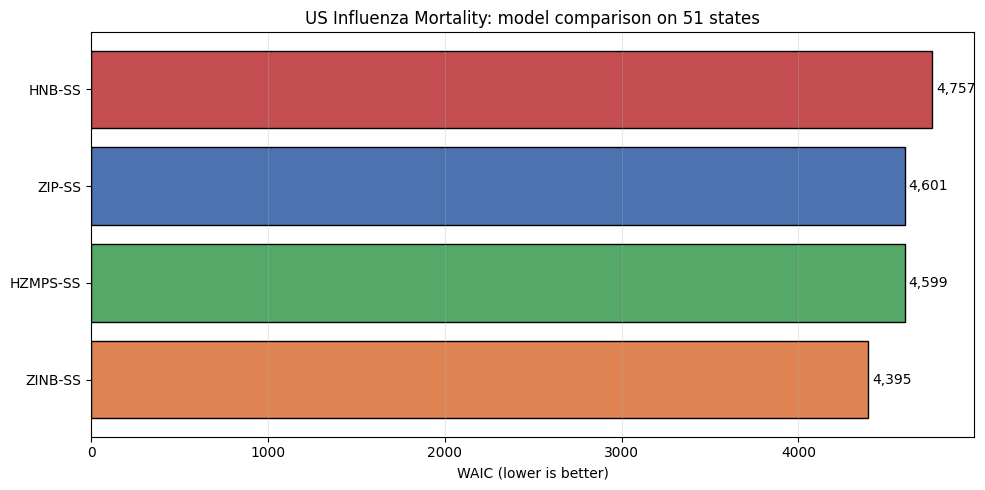

Figure saved.

CROSS-DISEASE SUMMARY
               Disease Best model  HZMPS ΔWAIC
       Dengue (Brazil)        ZIP  2083.000000
  Chikungunya (Brazil)        ZIP    94.000000
US Influenza Mortality    ZINB-SS   204.280543

Saved: cross_disease_summary.csv


In [10]:
# CELL 10: COMPARISON FIGURE
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#55A868' if 'HZMPS' in m else
          '#4C72B0' if 'ZIP' in m else
          '#DD8452' if 'ZINB' in m else '#C44E52'
          for m in results['Model']]
bars = ax.barh(results['Model'], results['WAIC'],
               color=colors, edgecolor='black')
for bar, w in zip(bars, results['WAIC']):
    ax.text(w + 20, bar.get_y() + bar.get_height()/2,
            f'{w:,.0f}', va='center', fontsize=10)
ax.set_xlabel('WAIC (lower is better)')
ax.set_title('US Influenza Mortality: model comparison on 51 states')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/flu_model_comparison.png', dpi=150)
plt.show()

print("Figure saved.")

# --- Cross-disease summary ---
print("\n" + "=" * 72)
print("CROSS-DISEASE SUMMARY")
print("=" * 72)
summary = pd.DataFrame([
    {'Disease': 'Dengue (Brazil)',      'Best model': 'ZIP',  'HZMPS ΔWAIC': 2083},
    {'Disease': 'Chikungunya (Brazil)', 'Best model': 'ZIP',  'HZMPS ΔWAIC': 94},
    {'Disease': 'US Influenza Mortality', 'Best model': results.iloc[0]['Model'],
     'HZMPS ΔWAIC': results[results['Model']=='HZMPS-SS']['ΔWAIC'].values[0]},
])
print(summary.to_string(index=False))
summary.to_csv('/content/cross_disease_summary.csv', index=False)
print("\nSaved: cross_disease_summary.csv")